# Musterloesung — Projekt 02 (medium): Das ehrliche Modellrennen

Vollstaendig ausgefuehrte Loesung zu `../model_race.ipynb`. Erst selbst versuchen!

## 1. Daten laden, explorieren, splitten

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

daten = load_breast_cancer()
X = pd.DataFrame(daten.data, columns=daten.feature_names)
y = daten.target  # 0 = malignant (boesartig), 1 = benign (gutartig)

print(X.shape)
print(pd.Series(y).map({0: "malignant", 1: "benign"}).value_counts(normalize=True))

(569, 30)
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {len(X_train)}, Test: {len(X_test)}")
print(abs(y_test.mean() - y.mean()) < 0.02)

Training: 455, Test: 114
True


## 2. Baseline

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"Dummy Accuracy: {dummy.score(X_test, y_test):.3f}  (ROC-AUC waere 0.5 - Zufall)")

Dummy Accuracy: 0.632  (ROC-AUC waere 0.5 - Zufall)


## 3. Pipelines fuer sechs Modellfamilien

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelle = {
    "Logistische Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))]),
    "kNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
    "SVM (RBF)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(probability=True))]),
    "Entscheidungsbaum": Pipeline([("scaler", StandardScaler()), ("clf", DecisionTreeClassifier(random_state=42))]),
    "Random Forest": Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(random_state=42))]),
    "Gradient Boosting": Pipeline([("scaler", StandardScaler()), ("clf", GradientBoostingClassifier(random_state=42))]),
}

print(list(modelle.keys()))
print(len(modelle) == 6)

['Logistische Regression', 'kNN', 'SVM (RBF)', 'Entscheidungsbaum', 'Random Forest', 'Gradient Boosting']
True


## 4. Fairer Vergleich per Kreuzvalidierung

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ergebnisse = {}
for name, pipeline in modelle.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    ergebnisse[name] = scores

for name, scores in ergebnisse.items():
    print(f"{name:25s}  ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

Logistische Regression     ROC-AUC = 0.9959 +/- 0.0050
kNN                        ROC-AUC = 0.9882 +/- 0.0081
SVM (RBF)                  ROC-AUC = 0.9956 +/- 0.0048
Entscheidungsbaum          ROC-AUC = 0.9179 +/- 0.0201
Random Forest              ROC-AUC = 0.9896 +/- 0.0083
Gradient Boosting          ROC-AUC = 0.9918 +/- 0.0053


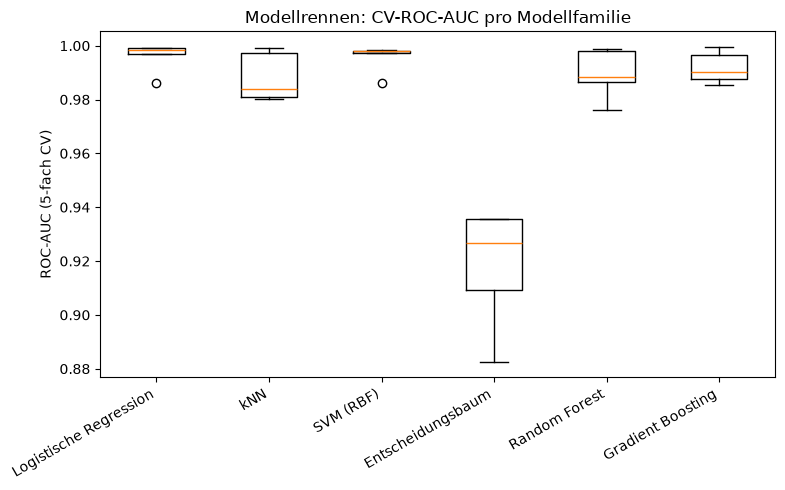

In [6]:
plt.figure(figsize=(8, 5))
plt.boxplot(ergebnisse.values(), tick_labels=ergebnisse.keys())
plt.xticks(rotation=30, ha="right")
plt.ylabel("ROC-AUC (5-fach CV)")
plt.title("Modellrennen: CV-ROC-AUC pro Modellfamilie")
plt.tight_layout()
plt.show()

**Auswertung:** Logistische Regression und Gradient Boosting liegen typischerweise vorn
(ROC-AUC oft > 0,99), mit enger Streuung ueber die 5 Folds — beide gehen ins Tuning.
Der Mittelwert allein reicht nicht: Ein Modell mit hoeherem Mittelwert, aber sehr breiter
Box (grosse Streuung zwischen den Folds) ist eine riskantere Wahl als ein Modell mit
minimal niedrigerem Mittelwert, aber stabilen Folds — die Streuung sagt etwas ueber die
Verlaesslichkeit der Schaetzung, nicht nur ihre Hoehe.

## 5. Hyperparameter-Tuning der Top 2

Hier: Logistische Regression und Gradient Boosting.

In [7]:
from sklearn.model_selection import GridSearchCV

grid_1 = {"clf__C": [0.01, 0.1, 1, 10, 100]}
suche_1 = GridSearchCV(modelle["Logistische Regression"], grid_1, cv=cv, scoring="roc_auc", n_jobs=-1)
suche_1.fit(X_train, y_train)

print(f"Bestes CV-ROC-AUC (Logistische Regression): {suche_1.best_score_:.4f}")
print(f"Beste Parameter: {suche_1.best_params_}")

Bestes CV-ROC-AUC (Logistische Regression): 0.9959
Beste Parameter: {'clf__C': 1}


In [8]:
grid_2 = {
    "clf__n_estimators": [100, 200, 400],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__max_depth": [2, 3, 4],
}
suche_2 = GridSearchCV(modelle["Gradient Boosting"], grid_2, cv=cv, scoring="roc_auc", n_jobs=-1)
suche_2.fit(X_train, y_train)

print(f"Bestes CV-ROC-AUC (Gradient Boosting): {suche_2.best_score_:.4f}")
print(f"Beste Parameter: {suche_2.best_params_}")

Bestes CV-ROC-AUC (Gradient Boosting): 0.9938
Beste Parameter: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}


## 6. Die einmalige Testauswertung

Gewaehltes Modell: Logistische Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Test-ROC-AUC: 0.9954


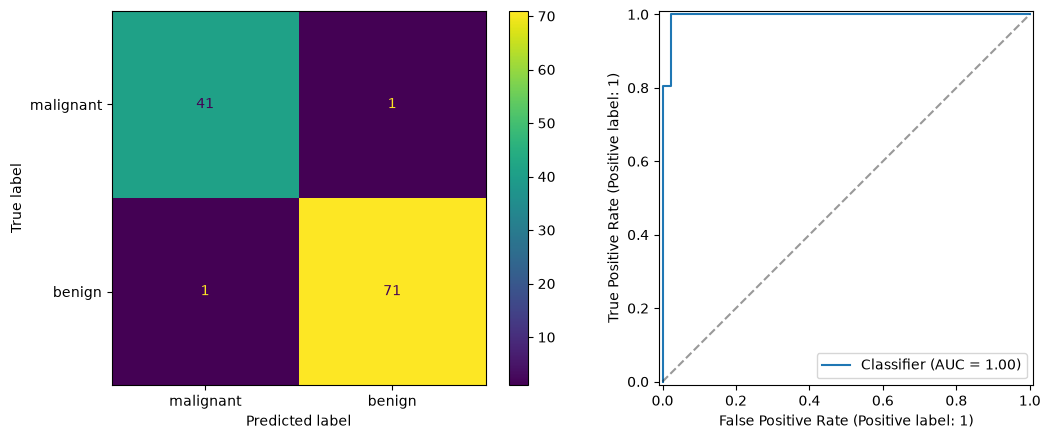

True


In [9]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay, roc_auc_score)

bestes_modell = suche_1.best_estimator_ if suche_1.best_score_ >= suche_2.best_score_ else suche_2.best_estimator_
print(f"Gewaehltes Modell: {'Logistische Regression' if bestes_modell is suche_1.best_estimator_ else 'Gradient Boosting'}")

y_pred = bestes_modell.predict(X_test)
y_proba = bestes_modell.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))
print(f"Test-ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

fig, achsen = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["malignant", "benign"], ax=achsen[0])
RocCurveDisplay.from_predictions(y_test, y_proba, ax=achsen[1])
achsen[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.tight_layout()
plt.show()

print(roc_auc_score(y_test, y_proba) > 0.97)

## 7. Interpretation: Permutation Importance

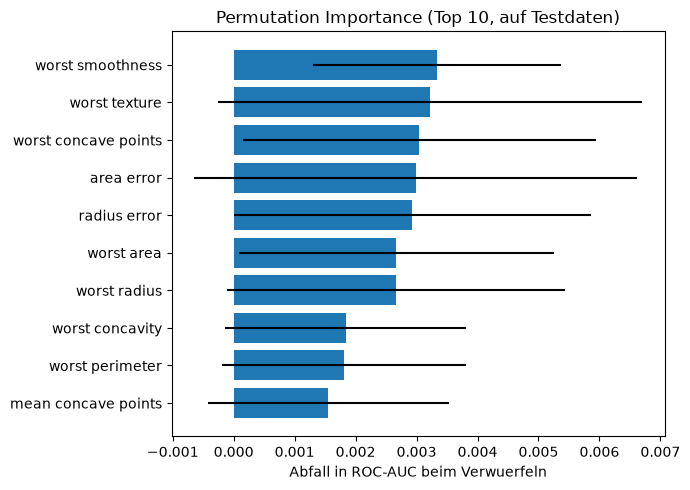

In [10]:
from sklearn.inspection import permutation_importance

wichtigkeit = permutation_importance(bestes_modell, X_test, y_test,
                                      n_repeats=30, random_state=42, scoring="roc_auc")

reihenfolge = np.argsort(wichtigkeit.importances_mean)[-10:]
plt.figure(figsize=(7, 5))
plt.barh(X.columns[reihenfolge], wichtigkeit.importances_mean[reihenfolge],
         xerr=wichtigkeit.importances_std[reihenfolge])
plt.xlabel("Abfall in ROC-AUC beim Verwuerfeln")
plt.title("Permutation Importance (Top 10, auf Testdaten)")
plt.tight_layout()
plt.show()

**Auswertung:** Ganz oben stehen erwartungsgemaess `worst`-Features wie `worst perimeter`,
`worst concave points`, `worst radius` oder `worst area` — groessere und unregelmaessiger
geformte Zellkerne sind ein bekanntes histopathologisches Malignitaetsmerkmal. Das
Modell nutzt also Merkmale, die auch klinisch Sinn ergeben (kein Garant fuer Kausalitaet,
siehe Skript 3.1, aber ein gutes Plausibilitaets-Signal).

## 8. Lernkurve: Bias- oder Varianz-Problem?

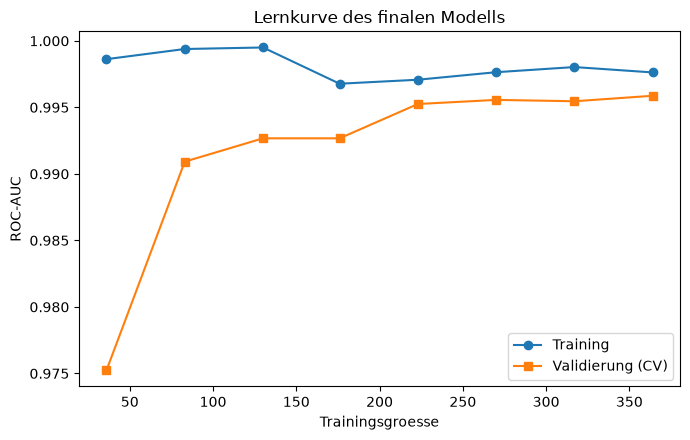

In [11]:
from sklearn.model_selection import learning_curve

groessen, train_scores, val_scores = learning_curve(
    bestes_modell, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=cv, scoring="roc_auc", n_jobs=-1)

plt.figure(figsize=(7, 4.5))
plt.plot(groessen, train_scores.mean(axis=1), marker="o", label="Training")
plt.plot(groessen, val_scores.mean(axis=1), marker="s", label="Validierung (CV)")
plt.xlabel("Trainingsgroesse"); plt.ylabel("ROC-AUC"); plt.legend()
plt.title("Lernkurve des finalen Modells")
plt.tight_layout()
plt.show()

**Auswertung:** Train- und Validierungskurve liegen nah beieinander und beide bereits
auf hohem Niveau (>0,98) — kein grosses Bias- oder Varianz-Problem. Die Validierungskurve
flacht mit wachsender Trainingsmenge ab; mehr Daten wuerden hier vermutlich kaum noch
etwas bringen. Das passt zum Gesamtbild: Der Datensatz ist fuer diese Modellfamilien
"leicht" trennbar.

## Geschafft — was du jetzt kannst

- Mehrere Modellfamilien konsistent in Pipelines verpacken
- Modelle fair per stratifizierter Kreuzvalidierung vergleichen (Mittelwert **und** Streuung lesen)
- Hyperparameter systematisch per GridSearchCV tunen, ohne den Testsatz anzufassen
- Am Ende **einmal** ehrlich testen und das Ergebnis mit Metriken, Kurven und
  Permutation Importance einordnen — inklusive Lernkurven-Diagnose

**Reflexionsfragen — Musterantworten:**

1. **Accuracy ohne Ueberlegung waere problematisch**, weil bei ~63/37-Klassenverteilung
   ein Modell, das oft "benign" rät, schon hohe Accuracy erreicht, ohne malignant-Faelle
   gut zu erkennen. ROC-AUC (schwellenunabhaengig) bzw. bei starker Unausgewogenheit
   PR-AUC sind hier die ehrlicheren Metriken (Skript 1.5).
2. **Nicht automatisch.** Eine hoehere mittlere CV-ROC-AUC bei grosser Streuung bedeutet,
   dass die tatsaechliche Leistung auf neuen Daten unsicherer ist. Ob man das Modell trotzdem
   waehlt, haengt davon ab, wie gross der Mittelwert-Vorsprung im Verhaeltnis zur Streuung
   ist, und wie risikotolerant die Anwendung ist (z. B. medizinische Diagnose: Stabilitaet
   zaehlt oft mehr als 0,3 Prozentpunkte Durchschnitts-AUC).
3. Bei 10x teureren False Positives wuerde man die **Entscheidungsschwelle** (Skript 2.6)
   nicht bei 0,5 belassen, sondern anhand der PR-Kurve/Kostenrechnung auf der
   Validierungsmenge so verschieben, dass Precision steigt (weniger falsche Alarme),
   auch wenn dafuer Recall sinkt — die Metrikwahl in Schritt 6 muesste diese Kostenasymmetrie
   explizit abbilden statt nur ROC-AUC/F1 zu berichten.